## Formal VaR Backtesting: Kupiec and Christoffersen Tests

So far in [**01_The_Baseline_VaRs**](https://github.com/BenjaminZYT/Risk-Management/blob/main/VaRs_and_CVaRs/01_The_Baseline_VaRs.ipynb), we have evaluated each VaR model by comparing the observed violation rate,

$$
\hat{p}
=
\frac{\text{number of VaR violations}}{\text{number of VaR forecasts}},
$$

with the target violation probability,

$$
p = 1-q.
$$

This is the basic idea behind VaR backtesting. A good VaR model should produce violations at approximately the intended rate. For example, a 95% VaR model should be violated about 5% of the time, while a 99% VaR model should be violated about 1% of the time.

The Kupiec and Christoffersen tests formalize this idea.

### Kupiec Unconditional Coverage Test

The Kupiec test checks whether the total number of observed VaR violations is statistically consistent with the expected violation probability $p=1-q$.

The null hypothesis is

$$
H_0: \hat{p}=p.
$$

Thus, the Kupiec test is a formal version of asking whether the observed violation rate is close enough to the target violation rate. A large p-value means there is not enough evidence to reject the VaR model's violation frequency. A small p-value means the model produces too many or too few violations relative to the target.

### Christoffersen Conditional Coverage Test

The Christoffersen test goes beyond the total violation count. It also considers whether violations are independent over time.

This matters because a VaR model may produce approximately the right total number of violations, but still fail if those violations are strongly clustered during stress periods. Such clustering suggests that the model is slow to adjust when risk conditions change.

In short:

- Kupiec test checks violation frequency, while
- Christoffersen test checks violation frequency and violation clustering.

### How These Tests Fit This Notebook

These tests are directly related to what we have already done in `01_The_Baseline_VaRs`. The earlier calibration tables classified each model as `Close to target`, `Conservative`, or `Underestimates risk` by comparing observed violation rates with target violation rates. The Kupiec test turns that comparison into a standard statistical test. The Christoffersen test adds the additional requirement that VaR violations should not arrive in excessive clusters.

We conduct both tests for all three baseline VaR models:

1. Historical VaR;
2. Normal VaR;
3. Student-$t$ VaR with $\nu=5$.

We also conduct the tests at all three VaR confidence levels:

$$
q \in \{0.95,0.99,0.995\}.
$$

The tests use the saved files produced earlier in `01_The_Baseline_VaRs`, which are available in the [data folder](https://github.com/BenjaminZYT/Risk-Management/tree/main/VaRs_and_CVaRs/data_VaRs_CVaRs) of this project subfolder:

```text
01_prices.csv
01_returns.csv
01_losses.csv

01_historical_var_results_window_2000.csv
01_normal_var_results_window_2000.csv
01_student_t_var_results_window_2000_dof_5.csv

01_historical_var_summary_window_2000.csv
01_normal_var_summary_window_2000.csv
01_student_t_var_summary_window_2000_dof_5.csv

---

## Loading the Baseline VaR Data

This notebook continues from `01_The_Baseline_VaRs`. In that notebook, we computed Historical VaR, Normal VaR, and Student-$t$ VaR for the same global equity-index dataset. Here, we reload the saved price, return, loss, and baseline result files so that the formal backtesting tests can be performed in a separate notebook.

The Kupiec and Christoffersen tests require the sequence of VaR violations. Since the earlier saved result files summarize the model outcomes but do not store every daily violation sequence, we reload the loss data and recompute the rolling VaR forecasts for each baseline model. This keeps the test notebook self-contained while using the same data, window length, confidence levels, and model choices as the baseline VaR notebook.

In [4]:
# ============================================================
# Load Data and Existing Baseline VaR Summary Files
# ============================================================

import os
import numpy as np
import pandas as pd
from scipy.stats import norm, t, chi2

WINDOW_LENGTH = 2000
VAR_LEVELS = [0.95, 0.99, 0.995]
STUDENT_T_DOF = 5

prices = pd.read_csv(
    "01_prices.csv",
    index_col=0,
    parse_dates=True,
)

returns = pd.read_csv(
    "01_returns.csv",
    index_col=0,
    parse_dates=True,
)

losses = pd.read_csv(
    "01_losses.csv",
    index_col=0,
    parse_dates=True,
)

historical_var_results_df = pd.read_csv(
    f"01_historical_var_results_window_{WINDOW_LENGTH}.csv"
)

normal_var_results_df = pd.read_csv(
    f"01_normal_var_results_window_{WINDOW_LENGTH}.csv"
)

student_t_var_results_df = pd.read_csv(
    f"01_student_t_var_results_window_{WINDOW_LENGTH}_dof_{STUDENT_T_DOF}.csv"
)

print("Loaded data and baseline VaR result files.")

Loaded data and baseline VaR result files.


## Recomputing VaR Forecasts and Violation Sequences

For each index, model, and VaR confidence level, we recompute the rolling one-step-ahead VaR forecasts using the same 2000-day window as before. A violation occurs when the realized loss exceeds the forecasted VaR threshold:

$$
L_t > \widehat{\operatorname{VaR}}_{q,t}.
$$

The resulting violation sequence is the input for the Kupiec and Christoffersen tests. The Kupiec test uses the total number of violations, while the Christoffersen test also uses the order in which violations occur.

In [5]:
# ============================================================
# Recompute Rolling VaR Forecasts and Violation Sequences
# ============================================================

def historical_var_forecasts(loss_series, q, window_length):
    """
    Rolling one-step-ahead Historical VaR forecasts.
    """
    loss_series = loss_series.dropna().astype(float)

    if len(loss_series) <= window_length:
        return pd.Series(dtype=float), pd.Series(dtype=float)

    forecast_index = loss_series.index[window_length:]
    realized_losses = loss_series.loc[forecast_index]
    var_forecasts = pd.Series(index=forecast_index, dtype=float)

    for date in forecast_index:
        date_pos = loss_series.index.get_loc(date)
        window_losses = loss_series.iloc[date_pos - window_length:date_pos]
        var_forecasts.loc[date] = window_losses.quantile(q)

    return realized_losses, var_forecasts


def normal_var_forecasts(loss_series, q, window_length):
    """
    Rolling one-step-ahead Normal VaR forecasts.
    """
    loss_series = loss_series.dropna().astype(float)

    if len(loss_series) <= window_length:
        return pd.Series(dtype=float), pd.Series(dtype=float)

    forecast_index = loss_series.index[window_length:]
    realized_losses = loss_series.loc[forecast_index]
    var_forecasts = pd.Series(index=forecast_index, dtype=float)

    z_q = norm.ppf(q)

    for date in forecast_index:
        date_pos = loss_series.index.get_loc(date)
        window_losses = loss_series.iloc[date_pos - window_length:date_pos]

        mu_hat = window_losses.mean()
        sigma_hat = window_losses.std(ddof=1)

        var_forecasts.loc[date] = mu_hat + sigma_hat * z_q

    return realized_losses, var_forecasts


def student_t_var_forecasts(loss_series, q, window_length, dof=5):
    """
    Rolling one-step-ahead Student-t VaR forecasts with fixed degrees of freedom.
    """
    loss_series = loss_series.dropna().astype(float)

    if len(loss_series) <= window_length:
        return pd.Series(dtype=float), pd.Series(dtype=float)

    forecast_index = loss_series.index[window_length:]
    realized_losses = loss_series.loc[forecast_index]
    var_forecasts = pd.Series(index=forecast_index, dtype=float)

    # scipy's Student-t has variance dof / (dof - 2), so standardize it to variance 1.
    t_q = t.ppf(q, df=dof) / np.sqrt(dof / (dof - 2))

    for date in forecast_index:
        date_pos = loss_series.index.get_loc(date)
        window_losses = loss_series.iloc[date_pos - window_length:date_pos]

        mu_hat = window_losses.mean()
        sigma_hat = window_losses.std(ddof=1)

        var_forecasts.loc[date] = mu_hat + sigma_hat * t_q

    return realized_losses, var_forecasts


def build_violation_sequences(losses, window_length, var_levels, student_t_dof=5):
    """
    Recompute rolling VaR forecasts and store violation sequences
    for all indices, models, and VaR levels.
    """
    rows = []
    sequences = {}

    model_specs = {
        "Historical VaR": historical_var_forecasts,
        "Normal VaR": normal_var_forecasts,
        f"Student-t VaR, DoF={student_t_dof}": lambda s, q, w: student_t_var_forecasts(
            s,
            q,
            w,
            dof=student_t_dof,
        ),
    }

    for index_name in losses.columns:
        loss_series = losses[index_name].dropna()

        for model_name, forecast_func in model_specs.items():
            print(f"Computing violations: {index_name}, {model_name}")

            for q in var_levels:
                realized_losses, var_forecasts = forecast_func(
                    loss_series,
                    q,
                    window_length,
                )

                common_index = realized_losses.index.intersection(var_forecasts.index)
                realized_losses = realized_losses.loc[common_index]
                var_forecasts = var_forecasts.loc[common_index]

                valid_mask = realized_losses.notna() & var_forecasts.notna()
                realized_losses = realized_losses[valid_mask]
                var_forecasts = var_forecasts[valid_mask]

                violations = (realized_losses > var_forecasts).astype(int)

                key = (index_name, model_name, q)

                sequences[key] = pd.DataFrame({
                    "realized_loss": realized_losses,
                    "var_forecast": var_forecasts,
                    "violation": violations,
                })

                rows.append({
                    "Index": index_name,
                    "Model": model_name,
                    "VaR Level": q,
                    "Target Violation Rate": 1 - q,
                    "Num Forecasts": len(violations),
                    "Num Violations": int(violations.sum()),
                    "Violation Rate": violations.mean(),
                })

    violation_summary_df = pd.DataFrame(rows)

    return violation_summary_df, sequences


violation_summary_df, violation_sequences = build_violation_sequences(
    losses=losses,
    window_length=WINDOW_LENGTH,
    var_levels=VAR_LEVELS,
    student_t_dof=STUDENT_T_DOF,
)

violation_summary_df.head()

# ============================================================
# Save Violation Summary
# ============================================================

violation_summary_path = (
    f"02_baseline_var_violation_summary_window_{WINDOW_LENGTH}.csv"
)

violation_summary_df.to_csv(violation_summary_path, index=False)

print(f"Saved violation summary to: {violation_summary_path}")

Computing violations: S&P 500, Historical VaR
Computing violations: S&P 500, Normal VaR
Computing violations: S&P 500, Student-t VaR, DoF=5
Computing violations: Malaysia KLCI, Historical VaR
Computing violations: Malaysia KLCI, Normal VaR
Computing violations: Malaysia KLCI, Student-t VaR, DoF=5
Computing violations: FTSE 100, Historical VaR
Computing violations: FTSE 100, Normal VaR
Computing violations: FTSE 100, Student-t VaR, DoF=5
Computing violations: Dubai DFMGI, Historical VaR
Computing violations: Dubai DFMGI, Normal VaR
Computing violations: Dubai DFMGI, Student-t VaR, DoF=5
Computing violations: Singapore STI, Historical VaR
Computing violations: Singapore STI, Normal VaR
Computing violations: Singapore STI, Student-t VaR, DoF=5
Computing violations: Hong Kong HSI, Historical VaR
Computing violations: Hong Kong HSI, Normal VaR
Computing violations: Hong Kong HSI, Student-t VaR, DoF=5
Computing violations: Shanghai Composite, Historical VaR
Computing violations: Shanghai Com

## Recomputing Violation Sequences

The saved baseline result files contain model-level summaries, such as violation rates and calibration labels. However, the Kupiec and Christoffersen tests require the underlying daily violation sequence.

For each index, model, and VaR confidence level, we therefore recompute the rolling one-step-ahead VaR forecasts using the same settings as in `01_The_Baseline_VaRs`:

$$
\ell = 2000,
\qquad
q \in \{0.95,0.99,0.995\}.
$$

A VaR violation occurs when the realized loss exceeds the forecasted VaR threshold:

$$
L_t > \widehat{\operatorname{VaR}}_{q,t}.
$$

The resulting sequence of zeros and ones is then used for the formal backtesting tests. Kupiec's test uses the total number of violations, while Christoffersen's test also uses the ordering of violations to detect clustering.

In [7]:
# ============================================================
# Recompute Rolling VaR Forecasts and Violation Sequences
# ============================================================

def historical_var_forecasts(loss_series, q, window_length):
    """
    Rolling one-step-ahead Historical VaR forecasts.
    """
    loss_series = loss_series.dropna().astype(float)

    if len(loss_series) <= window_length:
        return pd.Series(dtype=float), pd.Series(dtype=float)

    forecast_index = loss_series.index[window_length:]
    realized_losses = loss_series.loc[forecast_index]
    var_forecasts = pd.Series(index=forecast_index, dtype=float)

    for date in forecast_index:
        date_pos = loss_series.index.get_loc(date)
        window_losses = loss_series.iloc[date_pos - window_length:date_pos]
        var_forecasts.loc[date] = window_losses.quantile(q)

    return realized_losses, var_forecasts


def normal_var_forecasts(loss_series, q, window_length):
    """
    Rolling one-step-ahead Normal VaR forecasts.
    """
    loss_series = loss_series.dropna().astype(float)

    if len(loss_series) <= window_length:
        return pd.Series(dtype=float), pd.Series(dtype=float)

    forecast_index = loss_series.index[window_length:]
    realized_losses = loss_series.loc[forecast_index]
    var_forecasts = pd.Series(index=forecast_index, dtype=float)

    z_q = norm.ppf(q)

    for date in forecast_index:
        date_pos = loss_series.index.get_loc(date)
        window_losses = loss_series.iloc[date_pos - window_length:date_pos]

        mu_hat = window_losses.mean()
        sigma_hat = window_losses.std(ddof=1)

        var_forecasts.loc[date] = mu_hat + sigma_hat * z_q

    return realized_losses, var_forecasts


def student_t_var_forecasts(loss_series, q, window_length, dof=5):
    """
    Rolling one-step-ahead Student-t VaR forecasts with fixed degrees of freedom.
    """
    loss_series = loss_series.dropna().astype(float)

    if len(loss_series) <= window_length:
        return pd.Series(dtype=float), pd.Series(dtype=float)

    forecast_index = loss_series.index[window_length:]
    realized_losses = loss_series.loc[forecast_index]
    var_forecasts = pd.Series(index=forecast_index, dtype=float)

    # scipy's Student-t has variance dof / (dof - 2), so standardize it to variance 1.
    t_q = t.ppf(q, df=dof) / np.sqrt(dof / (dof - 2))

    for date in forecast_index:
        date_pos = loss_series.index.get_loc(date)
        window_losses = loss_series.iloc[date_pos - window_length:date_pos]

        mu_hat = window_losses.mean()
        sigma_hat = window_losses.std(ddof=1)

        var_forecasts.loc[date] = mu_hat + sigma_hat * t_q

    return realized_losses, var_forecasts


def build_violation_sequences(losses, window_length, var_levels, student_t_dof=5):
    """
    Recompute rolling VaR forecasts and store violation sequences
    for all indices, models, and VaR levels.
    """
    rows = []
    sequences = {}

    model_specs = {
        "Historical VaR": historical_var_forecasts,
        "Normal VaR": normal_var_forecasts,
        f"Student-t VaR, DoF={student_t_dof}": lambda s, q, w: student_t_var_forecasts(
            s, q, w, dof=student_t_dof
        ),
    }

    for index_name in losses.columns:
        loss_series = losses[index_name].dropna()

        for model_name, forecast_func in model_specs.items():
            print(f"Computing violations: {index_name}, {model_name}")

            for q in var_levels:
                realized_losses, var_forecasts = forecast_func(
                    loss_series,
                    q,
                    window_length,
                )

                common_index = realized_losses.index.intersection(var_forecasts.index)
                realized_losses = realized_losses.loc[common_index]
                var_forecasts = var_forecasts.loc[common_index]

                valid_mask = realized_losses.notna() & var_forecasts.notna()
                realized_losses = realized_losses[valid_mask]
                var_forecasts = var_forecasts[valid_mask]

                violations = (realized_losses > var_forecasts).astype(int)

                key = (index_name, model_name, q)

                sequences[key] = pd.DataFrame({
                    "realized_loss": realized_losses,
                    "var_forecast": var_forecasts,
                    "violation": violations,
                })

                rows.append({
                    "Index": index_name,
                    "Model": model_name,
                    "VaR Level": q,
                    "Target Violation Rate": 1 - q,
                    "Num Forecasts": len(violations),
                    "Num Violations": int(violations.sum()),
                    "Violation Rate": violations.mean(),
                })

    violation_summary_df = pd.DataFrame(rows)

    return violation_summary_df, sequences


violation_summary_df, violation_sequences = build_violation_sequences(
    losses=losses,
    window_length=WINDOW_LENGTH,
    var_levels=VAR_LEVELS,
    student_t_dof=STUDENT_T_DOF,
)

# ============================================================
# Save Violation Summary
# ============================================================

violation_summary_path = (
    f"02_baseline_var_violation_summary_window_{WINDOW_LENGTH}.csv"
)

violation_summary_df.to_csv(violation_summary_path, index=False)

print(f"Saved violation summary to: {violation_summary_path}")

Computing violations: S&P 500, Historical VaR
Computing violations: S&P 500, Normal VaR
Computing violations: S&P 500, Student-t VaR, DoF=5
Computing violations: Malaysia KLCI, Historical VaR
Computing violations: Malaysia KLCI, Normal VaR
Computing violations: Malaysia KLCI, Student-t VaR, DoF=5
Computing violations: FTSE 100, Historical VaR
Computing violations: FTSE 100, Normal VaR
Computing violations: FTSE 100, Student-t VaR, DoF=5
Computing violations: Dubai DFMGI, Historical VaR
Computing violations: Dubai DFMGI, Normal VaR
Computing violations: Dubai DFMGI, Student-t VaR, DoF=5
Computing violations: Singapore STI, Historical VaR
Computing violations: Singapore STI, Normal VaR
Computing violations: Singapore STI, Student-t VaR, DoF=5
Computing violations: Hong Kong HSI, Historical VaR
Computing violations: Hong Kong HSI, Normal VaR
Computing violations: Hong Kong HSI, Student-t VaR, DoF=5
Computing violations: Shanghai Composite, Historical VaR
Computing violations: Shanghai Com

In [8]:
violation_summary_df.head(10)

,Index,Model,VaR Level,Target Violation Rate,Num Forecasts,Num Violations,Violation Rate
0,S&P 500,Historical VaR,0.950,0.050,3864,165,0.042702
1,S&P 500,Historical VaR,0.990,0.010,3864,38,0.009834
2,S&P 500,Historical VaR,0.995,0.005,3864,22,0.005694
3,S&P 500,Normal VaR,0.950,0.050,3864,145,0.037526
4,S&P 500,Normal VaR,0.990,0.010,3864,68,0.017598
5,S&P 500,Normal VaR,0.995,0.005,3864,56,0.014493
6,S&P 500,"Student-t VaR, DoF=5",0.950,0.050,3864,161,0.041667
7,S&P 500,"Student-t VaR, DoF=5",0.990,0.010,3864,54,0.013975
8,S&P 500,"Student-t VaR, DoF=5",0.995,0.005,3864,34,0.008799
9,Malaysia KLCI,Historical VaR,0.950,0.050,3717,158,0.042507


## Kupiec Unconditional Coverage Test

The Kupiec test checks whether the observed number of VaR violations is statistically consistent with the target violation probability.

For a VaR confidence level $q$, the target violation probability is

$$
p = 1-q.
$$

If there are $T$ VaR forecasts and $N$ violations, then the observed violation rate is

$$
\hat{p} = \frac{N}{T}.
$$

The null hypothesis is

$$
H_0: \hat{p}=p.
$$

A large p-value means that the observed violation count is not statistically inconsistent with the target violation probability. A small p-value means the model produces too many or too few violations relative to the intended VaR level.

In this section, we apply the Kupiec test to each index, model, and VaR confidence level.

In [9]:
# ============================================================
# Kupiec Unconditional Coverage Test
# ============================================================

def kupiec_test_from_violations(violations, target_p):
    """
    Kupiec unconditional coverage test.

    Parameters
    ----------
    violations : array-like
        Sequence of 0/1 VaR violation indicators.
    target_p : float
        Target violation probability, equal to 1 - q.

    Returns
    -------
    dict
        Test statistic and p-value.
    """
    violations = np.asarray(violations, dtype=int)

    T = len(violations)
    N = violations.sum()

    if T == 0:
        return {
            "Kupiec LR": np.nan,
            "Kupiec p-value": np.nan,
        }

    phat = N / T

    eps = 1e-12
    target_p = np.clip(target_p, eps, 1 - eps)
    phat = np.clip(phat, eps, 1 - eps)

    log_l_null = (T - N) * np.log(1 - target_p) + N * np.log(target_p)
    log_l_alt = (T - N) * np.log(1 - phat) + N * np.log(phat)

    lr_uc = -2 * (log_l_null - log_l_alt)
    p_value = 1 - chi2.cdf(lr_uc, df=1)

    return {
        "Kupiec LR": lr_uc,
        "Kupiec p-value": p_value,
    }


kupiec_results = []

for key, seq_df in violation_sequences.items():
    index_name, model_name, q = key

    violations = seq_df["violation"].dropna().astype(int).values
    target_p = 1 - q

    test_result = kupiec_test_from_violations(
        violations=violations,
        target_p=target_p,
    )

    kupiec_results.append({
        "Index": index_name,
        "Model": model_name,
        "VaR Level": q,
        "Target Violation Rate": target_p,
        "Num Forecasts": len(violations),
        "Num Violations": int(violations.sum()),
        "Violation Rate": violations.mean(),
        **test_result,
    })

kupiec_results_df = pd.DataFrame(kupiec_results)

kupiec_results_df["Kupiec Pass"] = kupiec_results_df["Kupiec p-value"] > 0.05

# ============================================================
# Save Kupiec Test Results
# ============================================================

kupiec_results_path = (
    f"02_kupiec_test_results_window_{WINDOW_LENGTH}.csv"
)

kupiec_results_df.to_csv(kupiec_results_path, index=False)

print(f"Saved Kupiec test results to: {kupiec_results_path}")

Saved Kupiec test results to: 02_kupiec_test_results_window_2000.csv


In [10]:
kupiec_results_df.head(10)

,Index,Model,VaR Level,Target Violation Rate,Num Forecasts,Num Violations,Violation Rate,Kupiec LR,Kupiec p-value,Kupiec Pass
0,S&P 500,Historical VaR,0.950,0.050,3864,165,0.042702,4.548539,3.294685e-02,False
1,S&P 500,Historical VaR,0.990,0.010,3864,38,0.009834,0.010766,9.173584e-01,True
2,S&P 500,Historical VaR,0.995,0.005,3864,22,0.005694,0.357540,5.498756e-01,True
3,S&P 500,Normal VaR,0.950,0.050,3864,145,0.037526,13.802413,2.030752e-04,False
4,S&P 500,Normal VaR,0.990,0.010,3864,68,0.017598,18.375798,1.813468e-05,False
5,S&P 500,Normal VaR,0.995,0.005,3864,56,0.014493,46.182679,1.077249e-11,False
6,S&P 500,"Student-t VaR, DoF=5",0.950,0.050,3864,161,0.041667,5.974093,1.451755e-02,False
7,S&P 500,"Student-t VaR, DoF=5",0.990,0.010,3864,54,0.013975,5.488930,1.913725e-02,False
8,S&P 500,"Student-t VaR, DoF=5",0.995,0.005,3864,34,0.008799,9.131063,2.513057e-03,False
9,Malaysia KLCI,Historical VaR,0.950,0.050,3717,158,0.042507,4.618099,3.163627e-02,False


In [11]:
# ============================================================
# Kupiec Pass Counts
# ============================================================

kupiec_pass_summary = (
    kupiec_results_df
    .groupby(["Model", "VaR Level"])["Kupiec Pass"]
    .sum()
    .unstack()
)

kupiec_pass_summary

VaR Level,0.950,0.990,0.995
Model,,,
Historical VaR,1,7,9
Normal VaR,0,3,0
"Student-t VaR, DoF=5",3,9,7


## Descriptive Calibration versus Formal Backtesting

The Kupiec test does not simply repeat the descriptive calibration summary from `01_The_Baseline_VaRs`. The two approaches are related, but they answer different questions.

In `01`, we classified each model as `Close to target`, `Conservative`, or `Underestimates risk` by comparing the observed violation rate with the target violation rate using a chosen tolerance band. This was a practical calibration summary.

The Kupiec test is stricter. It formally tests whether the observed number of violations is statistically consistent with the nominal violation probability $1-q$. With thousands of forecasts, even a deviation that looks small in percentage terms can become statistically significant.

Therefore, the Kupiec results do not negate the earlier conclusions. Rather, they refine them. The earlier summary tells us whether a model looks practically close to the target under a chosen tolerance rule. The Kupiec test tells us whether the violation count survives a formal statistical coverage test.

This distinction matters. A model may be practically conservative or close to target, but still fail Kupiec because the deviation from the nominal violation rate is statistically detectable. Conversely, a model may pass Kupiec even if it is not visually perfect, as long as the violation count is statistically plausible.

The main qualitative conclusion remains similar: Normal VaR is fragile in the tail, while Historical VaR and Student-$t$ VaR are more credible baseline methods at higher confidence levels. However, the Kupiec test shows that even the stronger baseline methods should not be accepted uncritically.

In [14]:
# ============================================================
# Load 01 Summary Files with Calibration Labels
# ============================================================

historical_var_summary_df = pd.read_csv(
    f"01_historical_var_summary_window_{WINDOW_LENGTH}.csv"
)

normal_var_summary_df = pd.read_csv(
    f"01_normal_var_summary_window_{WINDOW_LENGTH}.csv"
)

student_t_var_summary_df = pd.read_csv(
    f"01_student_t_var_summary_window_{WINDOW_LENGTH}_dof_{STUDENT_T_DOF}.csv"
)

In [15]:
# ============================================================
# Build Descriptive Calibration Counts from 01
# ============================================================

def calibration_counts(summary_df, model_name):
    """
    Count calibration labels by VaR level for one model.
    """
    count_df = (
        summary_df
        .groupby(["VaR Level", "calibration_status"])
        .size()
        .unstack(fill_value=0)
    )

    expected_cols = [
        "Close to target",
        "Conservative",
        "Underestimates risk",
    ]

    for col in expected_cols:
        if col not in count_df.columns:
            count_df[col] = 0

    count_df = count_df[expected_cols]
    count_df["Model"] = model_name

    return count_df.reset_index()


descriptive_counts_df = pd.concat(
    [
        calibration_counts(historical_var_summary_df, "Historical VaR"),
        calibration_counts(normal_var_summary_df, "Normal VaR"),
        calibration_counts(
            student_t_var_summary_df,
            f"Student-t VaR, DoF={STUDENT_T_DOF}",
        ),
    ],
    ignore_index=True,
)

descriptive_counts_df

calibration_status,VaR Level,Close to target,Conservative,Underestimates risk,Model
0,0.950,5,5,0,Historical VaR
1,0.990,7,3,0,Historical VaR
2,0.995,5,5,0,Historical VaR
3,0.950,5,5,0,Normal VaR
4,0.990,2,0,8,Normal VaR
5,0.995,0,0,10,Normal VaR
6,0.950,5,5,0,"Student-t VaR, DoF=5"
7,0.990,9,0,1,"Student-t VaR, DoF=5"
8,0.995,3,0,7,"Student-t VaR, DoF=5"


In [16]:
# ============================================================
# Build Kupiec Pass Counts from 02
# ============================================================

kupiec_counts_df = (
    kupiec_results_df
    .groupby(["Model", "VaR Level"])["Kupiec Pass"]
    .sum()
    .reset_index()
    .rename(columns={"Kupiec Pass": "Kupiec Pass Count"})
)

kupiec_counts_df

,Model,VaR Level,Kupiec Pass Count
0,Historical VaR,0.950,1
1,Historical VaR,0.990,7
2,Historical VaR,0.995,9
3,Normal VaR,0.950,0
4,Normal VaR,0.990,3
5,Normal VaR,0.995,0
6,"Student-t VaR, DoF=5",0.950,3
7,"Student-t VaR, DoF=5",0.990,9
8,"Student-t VaR, DoF=5",0.995,7


In [17]:
# ============================================================
# Combine Descriptive Calibration and Kupiec Results
# ============================================================

descriptive_vs_kupiec_df = descriptive_counts_df.merge(
    kupiec_counts_df,
    on=["Model", "VaR Level"],
    how="left",
)

descriptive_vs_kupiec_df = descriptive_vs_kupiec_df[
    [
        "Model",
        "VaR Level",
        "Close to target",
        "Conservative",
        "Underestimates risk",
        "Kupiec Pass Count",
    ]
]

descriptive_vs_kupiec_df

,Model,VaR Level,Close to target,Conservative,Underestimates risk,Kupiec Pass Count
0,Historical VaR,0.950,5,5,0,1
1,Historical VaR,0.990,7,3,0,7
2,Historical VaR,0.995,5,5,0,9
3,Normal VaR,0.950,5,5,0,0
4,Normal VaR,0.990,2,0,8,3
5,Normal VaR,0.995,0,0,10,0
6,"Student-t VaR, DoF=5",0.950,5,5,0,3
7,"Student-t VaR, DoF=5",0.990,9,0,1,9
8,"Student-t VaR, DoF=5",0.995,3,0,7,7


In [18]:
# ============================================================
# Save Descriptive-vs-Kupiec Comparison
# ============================================================

descriptive_vs_kupiec_df.to_csv(
    f"02_descriptive_vs_kupiec_comparison_window_{WINDOW_LENGTH}.csv",
    index=False,
)

print("Saved descriptive-vs-Kupiec comparison table.")

Saved descriptive-vs-Kupiec comparison table.


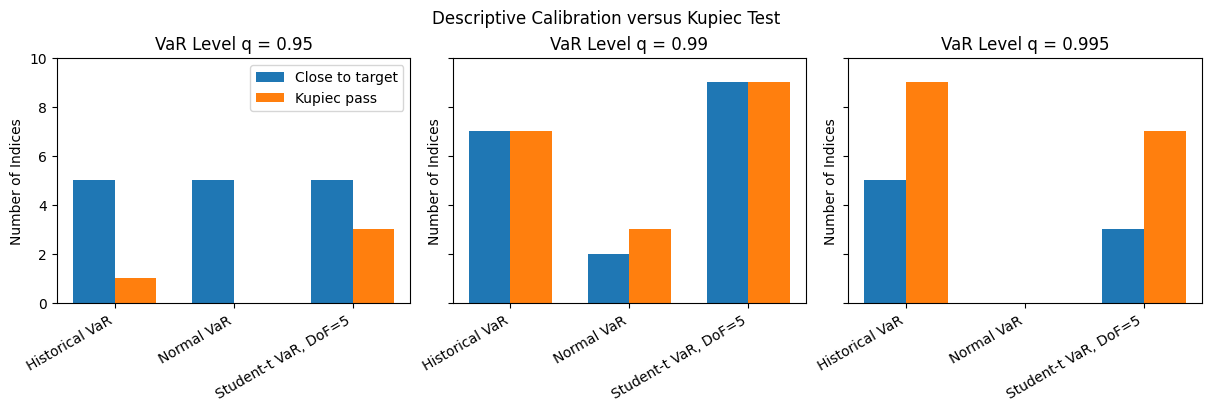

In [20]:
# ============================================================
# Plot: Close-to-Target Count versus Kupiec Pass Count
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

def plot_close_vs_kupiec(descriptive_vs_kupiec_df):
    var_levels = sorted(descriptive_vs_kupiec_df["VaR Level"].unique())
    models = descriptive_vs_kupiec_df["Model"].unique().tolist()

    fig, axes = plt.subplots(
        1,
        len(var_levels),
        figsize=(12, 4),
        sharey=True,
        constrained_layout=True,
    )

    if len(var_levels) == 1:
        axes = [axes]

    for ax, q in zip(axes, var_levels):
        df_q = (
            descriptive_vs_kupiec_df[
                descriptive_vs_kupiec_df["VaR Level"] == q
            ]
            .set_index("Model")
            .reindex(models)
            .reset_index()
        )

        x = np.arange(len(models))
        width = 0.35

        ax.bar(
            x - width / 2,
            df_q["Close to target"],
            width=width,
            label="Close to target",
        )

        ax.bar(
            x + width / 2,
            df_q["Kupiec Pass Count"],
            width=width,
            label="Kupiec pass",
        )

        ax.set_title(f"VaR Level q = {q}")
        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=30, ha="right")
        ax.set_ylabel("Number of Indices")
        ax.set_ylim(0, 10)

    axes[0].legend()
    fig.suptitle("Descriptive Calibration versus Kupiec Test")
    plt.show()


plot_close_vs_kupiec(descriptive_vs_kupiec_df)

The Kupiec test does not overturn the the descriptive conclusions in `01_The_Baseline_VaRs`, but it changes their sharpness. At 95%, the descriptive calibration labels were too forgiving. At 99% and 99.5%, the formal results reinforce the main ranking: Normal VaR is the weakest tail model, while Historical VaR and Student-$t$ VaR are more credible, with Historical VaR looking especially strong at the farthest tail.

---

## Christoffersen Conditional Coverage Test

The Christoffersen test extends the Kupiec test by asking not only whether the total number of VaR violations is reasonable, but also whether the violations are independent over time.

This matters because a VaR model can have the correct total number of violations but still fail as a risk model if the violations arrive in clusters. Clustered violations suggest that the model is slow to adjust during stress periods.

Let $I_t$ be the VaR violation indicator:

$$
I_t =
\begin{cases}
1, & L_t > \widehat{\operatorname{VaR}}_{q,t}, \\
0, & L_t \leq \widehat{\operatorname{VaR}}_{q,t}.
\end{cases}
$$

The Christoffersen test studies transitions in the violation sequence. Let $n_{ij}$ be the number of times state $i$ is followed by state $j$, where $i,j \in \{0,1\}$.

A large p-value means that the violation sequence does not show strong evidence against correct conditional coverage. A small p-value means that the VaR model may have incorrect violation frequency, violation clustering, or both.

In [21]:
# ============================================================
# Christoffersen Conditional Coverage Test
# ============================================================

def christoffersen_test_from_violations(violations, target_p):
    """
    Christoffersen conditional coverage test.

    This combines:
    1. Kupiec unconditional coverage test.
    2. Independence test for violation clustering.

    Parameters
    ----------
    violations : array-like
        Sequence of 0/1 VaR violation indicators.
    target_p : float
        Target violation probability, equal to 1 - q.

    Returns
    -------
    dict
        LR statistics, transition counts, and p-values.
    """
    violations = np.asarray(violations, dtype=int)

    T = len(violations)

    if T < 2:
        return {
            "n00": np.nan,
            "n01": np.nan,
            "n10": np.nan,
            "n11": np.nan,
            "Kupiec LR": np.nan,
            "Kupiec p-value": np.nan,
            "Independence LR": np.nan,
            "Independence p-value": np.nan,
            "Christoffersen LR": np.nan,
            "Christoffersen p-value": np.nan,
        }

    # Kupiec component
    kupiec_result = kupiec_test_from_violations(
        violations=violations,
        target_p=target_p,
    )

    lr_uc = kupiec_result["Kupiec LR"]
    kupiec_pvalue = kupiec_result["Kupiec p-value"]

    prev = violations[:-1]
    curr = violations[1:]

    n00 = int(np.sum((prev == 0) & (curr == 0)))
    n01 = int(np.sum((prev == 0) & (curr == 1)))
    n10 = int(np.sum((prev == 1) & (curr == 0)))
    n11 = int(np.sum((prev == 1) & (curr == 1)))

    eps = 1e-12

    # Transition probabilities under Markov alternative
    pi01 = n01 / (n00 + n01) if (n00 + n01) > 0 else 0
    pi11 = n11 / (n10 + n11) if (n10 + n11) > 0 else 0

    # Common violation probability under independence
    pi = (n01 + n11) / (n00 + n01 + n10 + n11)

    pi01 = np.clip(pi01, eps, 1 - eps)
    pi11 = np.clip(pi11, eps, 1 - eps)
    pi = np.clip(pi, eps, 1 - eps)

    log_l_independent = (
        (n00 + n10) * np.log(1 - pi)
        + (n01 + n11) * np.log(pi)
    )

    log_l_markov = (
        n00 * np.log(1 - pi01)
        + n01 * np.log(pi01)
        + n10 * np.log(1 - pi11)
        + n11 * np.log(pi11)
    )

    lr_ind = -2 * (log_l_independent - log_l_markov)
    ind_pvalue = 1 - chi2.cdf(lr_ind, df=1)

    lr_cc = lr_uc + lr_ind
    cc_pvalue = 1 - chi2.cdf(lr_cc, df=2)

    return {
        "n00": n00,
        "n01": n01,
        "n10": n10,
        "n11": n11,
        "Kupiec LR": lr_uc,
        "Kupiec p-value": kupiec_pvalue,
        "Independence LR": lr_ind,
        "Independence p-value": ind_pvalue,
        "Christoffersen LR": lr_cc,
        "Christoffersen p-value": cc_pvalue,
    }

In [22]:
# ============================================================
# Run Christoffersen Test Across All Violation Sequences
# ============================================================

christoffersen_results = []

for key, seq_df in violation_sequences.items():
    index_name, model_name, q = key

    violations = seq_df["violation"].dropna().astype(int).values
    target_p = 1 - q

    test_result = christoffersen_test_from_violations(
        violations=violations,
        target_p=target_p,
    )

    christoffersen_results.append({
        "Index": index_name,
        "Model": model_name,
        "VaR Level": q,
        "Target Violation Rate": target_p,
        "Num Forecasts": len(violations),
        "Num Violations": int(violations.sum()),
        "Violation Rate": violations.mean(),
        **test_result,
    })

christoffersen_results_df = pd.DataFrame(christoffersen_results)

christoffersen_results_df["Independence Pass"] = (
    christoffersen_results_df["Independence p-value"] > 0.05
)

christoffersen_results_df["Christoffersen Pass"] = (
    christoffersen_results_df["Christoffersen p-value"] > 0.05
)

# ============================================================
# Save Christoffersen Test Results
# ============================================================

christoffersen_results_path = (
    f"02_christoffersen_test_results_window_{WINDOW_LENGTH}.csv"
)

christoffersen_results_df.to_csv(christoffersen_results_path, index=False)

print(f"Saved Christoffersen test results to: {christoffersen_results_path}")

Saved Christoffersen test results to: 02_christoffersen_test_results_window_2000.csv


In [23]:
christoffersen_results_df.head(12)

,Index,Model,VaR Level,Target Violation Rate,Num Forecasts,Num Violations,Violation Rate,n00,n01,n10,n11,Kupiec LR,Kupiec p-value,Independence LR,Independence p-value,Christoffersen LR,Christoffersen p-value,Independence Pass,Christoffersen Pass
0,S&P 500,Historical VaR,0.950,0.050,3864,165,0.042702,3558,140,140,25,4.548539,3.294685e-02,31.740220,1.762345e-08,36.288759,1.318245e-08,False,False
1,S&P 500,Historical VaR,0.990,0.010,3864,38,0.009834,3790,35,35,3,0.010766,9.173584e-01,7.620704,5.770197e-03,7.631470,2.202152e-02,False,False
2,S&P 500,Historical VaR,0.995,0.005,3864,22,0.005694,3822,19,19,3,0.357540,5.498756e-01,14.098139,1.735154e-04,14.455679,7.260880e-04,False,False
3,S&P 500,Normal VaR,0.950,0.050,3864,145,0.037526,3596,122,122,23,13.802413,2.030752e-04,35.883284,2.094985e-09,49.685697,1.625133e-11,False,False
4,S&P 500,Normal VaR,0.990,0.010,3864,68,0.017598,3734,61,61,7,18.375798,1.813468e-05,14.167054,1.672740e-04,32.542852,8.578463e-08,False,False
5,S&P 500,Normal VaR,0.995,0.005,3864,56,0.014493,3756,51,51,5,46.182679,1.077249e-11,10.460020,1.219860e-03,56.642698,5.013767e-13,False,False
6,S&P 500,"Student-t VaR, DoF=5",0.950,0.050,3864,161,0.041667,3566,136,136,25,5.974093,1.451755e-02,33.796150,6.119986e-09,39.770243,2.312073e-09,False,False
7,S&P 500,"Student-t VaR, DoF=5",0.990,0.010,3864,54,0.013975,3760,49,49,5,5.488930,1.913725e-02,11.116856,8.554669e-04,16.605786,2.477989e-04,False,False
8,S&P 500,"Student-t VaR, DoF=5",0.995,0.005,3864,34,0.008799,3798,31,31,3,9.131063,2.513057e-03,8.875886,2.889620e-03,18.006949,1.229818e-04,False,False
9,Malaysia KLCI,Historical VaR,0.950,0.050,3717,158,0.042507,3420,138,138,20,4.618099,3.163627e-02,19.529128,9.907734e-06,24.147227,5.708161e-06,False,False


In [24]:
# ============================================================
# Christoffersen Pass Counts
# ============================================================

christoffersen_pass_summary = (
    christoffersen_results_df
    .groupby(["Model", "VaR Level"])["Christoffersen Pass"]
    .sum()
    .unstack()
)

christoffersen_pass_summary

VaR Level,0.950,0.990,0.995
Model,,,
Historical VaR,1,1,3
Normal VaR,1,1,0
"Student-t VaR, DoF=5",1,2,3


## Christoffersen Test Results

The Christoffersen conditional coverage test gives much stricter results than the Kupiec test. This is expected because Kupiec only tests whether the total number of VaR violations is statistically consistent with the target violation probability, while Christoffersen also checks whether those violations are independent over time.

The pass counts are low across all three baseline models. Historical VaR passes for 1 index at the 95% level, 1 index at the 99% level, and 3 indices at the 99.5% level. Normal VaR performs weakest overall, passing for 1, 1, and 0 indices respectively. Student-$t$ VaR performs slightly better, passing for 1, 2, and 3 indices respectively.

These results suggest that the baseline VaR models may sometimes get the total number of violations approximately right, but they often fail the stronger requirement that violations should not cluster. This is plausible for equity-index data because losses tend to cluster during stress periods, crises, and high-volatility regimes.

Thus, the Christoffersen test does not merely say that the models are badly calibrated. More specifically, it suggests that these simple baseline models are not sufficiently adaptive to changing market conditions. This provides motivation for later notebooks on filtered historical simulation, GARCH-based VaR, EVT-based VaR, and other methods designed to respond more explicitly to volatility clustering and tail behavior.

In [26]:
# ============================================================
# Kupiec versus Christoffersen Pass Counts
# ============================================================

kupiec_pass_long = (
    kupiec_results_df
    .groupby(["Model", "VaR Level"])["Kupiec Pass"]
    .sum()
    .reset_index()
    .rename(columns={"Kupiec Pass": "Kupiec Pass Count"})
)

christoffersen_pass_long = (
    christoffersen_results_df
    .groupby(["Model", "VaR Level"])["Christoffersen Pass"]
    .sum()
    .reset_index()
    .rename(columns={"Christoffersen Pass": "Christoffersen Pass Count"})
)

kupiec_vs_christoffersen_df = kupiec_pass_long.merge(
    christoffersen_pass_long,
    on=["Model", "VaR Level"],
    how="inner",
)

# ============================================================
# Save Kupiec-versus-Christoffersen Comparison
# ============================================================

kupiec_vs_christoffersen_df.to_csv(
    f"02_kupiec_vs_christoffersen_comparison_window_{WINDOW_LENGTH}.csv",
    index=False,
)

print("Saved Kupiec-versus-Christoffersen comparison table.")

kupiec_vs_christoffersen_df

Saved Kupiec-versus-Christoffersen comparison table.


,Model,VaR Level,Kupiec Pass Count,Christoffersen Pass Count
0,Historical VaR,0.950,1,1
1,Historical VaR,0.990,7,1
2,Historical VaR,0.995,9,3
3,Normal VaR,0.950,0,1
4,Normal VaR,0.990,3,1
5,Normal VaR,0.995,0,0
6,"Student-t VaR, DoF=5",0.950,3,1
7,"Student-t VaR, DoF=5",0.990,9,2
8,"Student-t VaR, DoF=5",0.995,7,3


## Kupiec versus Christoffersen Comparison

The comparison table makes the distinction between the two formal backtests clear.

The Kupiec test focuses on the total number of VaR violations. Under this test, Historical VaR and Student-$t$ VaR perform reasonably well at the higher confidence levels. Historical VaR passes for 7 out of 10 indices at the 99% level and 9 out of 10 indices at the 99.5% level. Student-$t$ VaR passes for 9 out of 10 indices at the 99% level and 7 out of 10 indices at the 99.5% level.

The Christoffersen test is stricter because it also accounts for the timing of violations. Once violation clustering is considered, the pass counts fall sharply. Historical VaR drops from 7 Kupiec passes to 1 Christoffersen pass at the 99% level, and from 9 to 3 at the 99.5% level. Student-$t$ VaR drops from 9 to 2 at the 99% level, and from 7 to 3 at the 99.5% level.

This suggests that the baseline models can sometimes get the overall violation frequency approximately right, but they often fail to handle the time dependence of violations. In equity-index data, large losses tend to cluster during stress periods, so a model that only captures the unconditional violation rate may still fail as a dynamic risk model.

Overall, the table reinforces the main lesson: baseline VaR methods are useful reference models, but their violations are often not independent over time. This motivates later notebooks on filtered historical simulation, GARCH-based VaR, EVT-based VaR, and other methods designed to respond more explicitly to volatility clustering and tail behavior.

## Descriptive Calibration, Kupiec, and Christoffersen Compared

The final comparison combines the three layers of VaR evaluation used in this notebook.

`Close to target` is the descriptive calibration count from `01_The_Baseline_VaRs`. It counts how many indices had violation rates close to the target violation probability under the chosen tolerance rule.

`Kupiec Pass Count` reports how many indices passed the formal unconditional coverage test. This checks whether the total number of violations is statistically consistent with the target violation probability.

`Christoffersen Pass Count` reports how many indices passed the conditional coverage test. This is the strictest criterion here because it checks both violation frequency and violation timing.

The comparison shows that descriptive calibration is the most forgiving criterion, Kupiec is stricter, and Christoffersen is usually the strictest. In particular, several models that look acceptable by violation-rate counts fail once clustering is considered.

This reinforces the central lesson: baseline VaR methods can be useful and interpretable, but passing a simple violation-rate check is not the same as passing formal dynamic backtesting. The sharp drop from Kupiec passes to Christoffersen passes suggests that violation clustering is a major issue for these baseline models.

In [27]:
# ============================================================
# Descriptive Calibration vs Kupiec vs Christoffersen
# ============================================================

# Start from descriptive-vs-Kupiec table already built earlier:
# descriptive_vs_kupiec_df
#
# Add Christoffersen pass counts.

christoffersen_counts_df = (
    christoffersen_results_df
    .groupby(["Model", "VaR Level"])["Christoffersen Pass"]
    .sum()
    .reset_index()
    .rename(columns={"Christoffersen Pass": "Christoffersen Pass Count"})
)

descriptive_kupiec_christoffersen_df = descriptive_vs_kupiec_df.merge(
    christoffersen_counts_df,
    on=["Model", "VaR Level"],
    how="left",
)

descriptive_kupiec_christoffersen_df = descriptive_kupiec_christoffersen_df[
    [
        "Model",
        "VaR Level",
        "Close to target",
        "Kupiec Pass Count",
        "Christoffersen Pass Count",
        "Conservative",
        "Underestimates risk",
    ]
]

# ============================================================
# Save Combined Comparison Table
# ============================================================

descriptive_kupiec_christoffersen_df.to_csv(
    f"02_descriptive_kupiec_christoffersen_comparison_window_{WINDOW_LENGTH}.csv",
    index=False,
)

print("Saved descriptive-Kupiec-Christoffersen comparison table.")

Saved descriptive-Kupiec-Christoffersen comparison table.


In [28]:
descriptive_kupiec_christoffersen_df

,Model,VaR Level,Close to target,Kupiec Pass Count,Christoffersen Pass Count,Conservative,Underestimates risk
0,Historical VaR,0.950,5,1,1,5,0
1,Historical VaR,0.990,7,7,1,3,0
2,Historical VaR,0.995,5,9,3,5,0
3,Normal VaR,0.950,5,0,1,5,0
4,Normal VaR,0.990,2,3,1,0,8
5,Normal VaR,0.995,0,0,0,0,10
6,"Student-t VaR, DoF=5",0.950,5,3,1,5,0
7,"Student-t VaR, DoF=5",0.990,9,9,2,0,1
8,"Student-t VaR, DoF=5",0.995,3,7,3,0,7


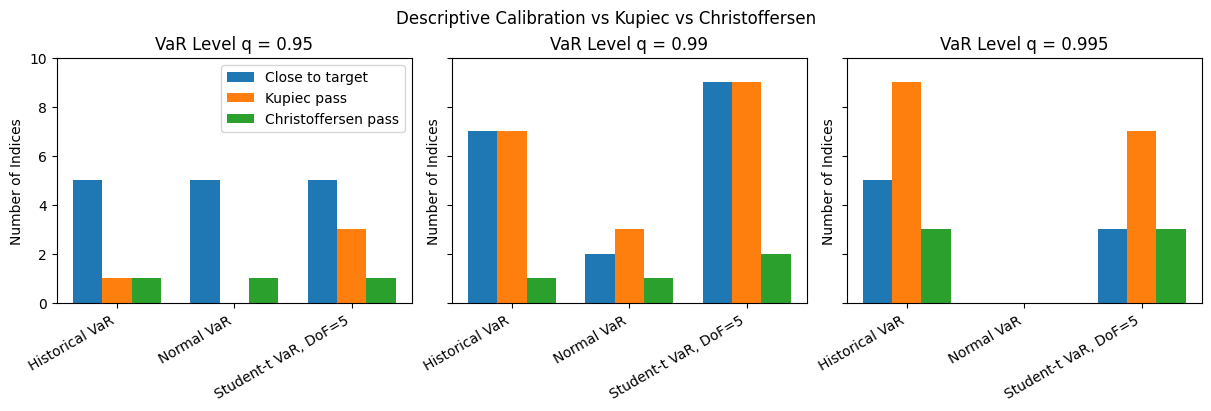

In [31]:
# ============================================================
# Plot: Descriptive vs Kupiec vs Christoffersen
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

def plot_descriptive_kupiec_christoffersen_comparison(comparison_df):
    """
    Grouped bar chart comparing:
    1. Close-to-target count
    2. Kupiec pass count
    3. Christoffersen pass count

    for each model and VaR level.
    """
    var_levels = sorted(comparison_df["VaR Level"].unique())
    models = comparison_df["Model"].unique().tolist()

    fig, axes = plt.subplots(
        1,
        len(var_levels),
        figsize=(12, 4),
        sharey=True,
        constrained_layout=True,
    )

    if len(var_levels) == 1:
        axes = [axes]

    for ax, q in zip(axes, var_levels):
        df_q = (
            comparison_df[comparison_df["VaR Level"] == q]
            .set_index("Model")
            .reindex(models)
            .reset_index()
        )

        x = np.arange(len(models))
        width = 0.25

        ax.bar(
            x - width,
            df_q["Close to target"],
            width=width,
            label="Close to target",
        )

        ax.bar(
            x,
            df_q["Kupiec Pass Count"],
            width=width,
            label="Kupiec pass",
        )

        ax.bar(
            x + width,
            df_q["Christoffersen Pass Count"],
            width=width,
            label="Christoffersen pass",
        )

        ax.set_title(f"VaR Level q = {q}")
        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=30, ha="right")
        ax.set_ylabel("Number of Indices")
        ax.set_ylim(0, 10)

    axes[0].legend()
    fig.suptitle("Descriptive Calibration vs Kupiec vs Christoffersen")
    plt.show()


plot_descriptive_kupiec_christoffersen_comparison(
    descriptive_kupiec_christoffersen_df
)

## The Three-Level Comparison

The table and plot compare three increasingly strict ways of judging the baseline VaR models.

`Close to target` is the descriptive calibration count from the baseline notebook. It asks whether the observed violation rate is practically close to the target rate under the chosen tolerance rule. `Kupiec Pass Count` is stricter: it asks whether the total number of violations is statistically consistent with the target violation probability. `Christoffersen Pass Count` is stricter still because it also checks whether violations are independent over time rather than clustered.

At the 95% VaR level, all three models have 5 indices classified as close to target, but their formal test performance is weak. Historical VaR passes Kupiec for only 1 index, Normal VaR passes for none, and Student-$t$ VaR passes for 3. Christoffersen pass counts are also very low. This means that the descriptive tolerance rule is relatively forgiving at the 95% level.

At the 99% VaR level, Historical VaR and Student-$t$ VaR perform much better under Kupiec. Historical VaR has 7 close-to-target cases and 7 Kupiec passes, while Student-$t$ VaR has 9 close-to-target cases and 9 Kupiec passes. Normal VaR remains weak because it underestimates risk for 8 indices. However, Christoffersen pass counts are still low, showing that even when violation counts are reasonable, violation clustering remains a problem.

At the 99.5% VaR level, Historical VaR is the strongest by Kupiec, passing 9 out of 10 indices and never underestimating risk under the descriptive classification. Student-$t$ VaR passes Kupiec for 7 indices but still underestimates risk for 7 indices descriptively. Normal VaR fails completely, with 0 close-to-target cases, 0 Kupiec passes, 0 Christoffersen passes, and 10 underestimation cases.

Overall, the comparison reinforces the main lesson: Normal VaR is the weakest tail-risk baseline, especially at high confidence levels. Historical VaR is conservative and performs well under Kupiec in the far tail, while Student-$t$ VaR improves substantially over Normal VaR, especially at 99%. However, all three baseline methods struggle under Christoffersen, suggesting that violation clustering is the main weakness.

## References

1. Kupiec, P. H. (1995). Techniques for verifying the accuracy of risk measurement models. *The Journal of Derivatives, 3*(2), 73–84. https://doi.org/10.3905/jod.1995.407942

2. Christoffersen, P. F. (1998). Evaluating interval forecasts. *International Economic Review, 39*(4), 841–862. https://doi.org/10.2307/2527341

3. Christoffersen, P. F. (2012). *Elements of Financial Risk Management* (2nd ed.). Academic Press. https://www.sciencedirect.com/book/9780123744487/elements-of-financial-risk-management